# Chapter 1.7: The Modern RecSys Pipeline

## Learning Objectives

By the end of this notebook, you will be able to:

1. Explain the multi-stage recommendation pipeline: Retrieval, Pre-ranking, Ranking, Re-ranking, Mix/Policy
2. Justify why multi-stage architectures are necessary (latency, compute, diversity)
3. Describe Meta's recommendation architecture at a high level
4. Describe Tencent's recommendation architecture at a high level
5. Map pipeline stages to real products (News Feed, Video Rec, E-commerce)
6. Analyze the tradeoffs at each pipeline stage
7. Design a recommendation pipeline for a given product scenario

## Prerequisites

- Chapter 1.1-1.6 (all previous chapters)
- General understanding of system design concepts (latency, throughput)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hideak1/rec_system/blob/main/notebooks/part1/chapter_1.7_modern_pipeline.ipynb)
[![Download](https://img.shields.io/badge/Download-Notebook-blue)](https://github.com/hideak1/rec_system/raw/main/notebooks/part1/chapter_1.7_modern_pipeline.ipynb)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict

np.random.seed(42)

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True

print("All imports successful!")

All imports successful!


## 1. Why Multi-Stage?

Consider an e-commerce platform with:
- 100 million items in the catalog
- Target latency: <200ms per request
- A deep ranking model that takes ~1ms per item

Ranking ALL items: $10^8 \times 1\text{ms} = 10^5\text{s} \approx 28\text{ hours}$

**Clearly impossible.** We need a funnel:

| Stage | Items | Model Complexity | Latency Budget |
|---|---|---|---|
| **Retrieval** | 100M -> ~10K | Simple (ANN, two-tower) | ~20ms |
| **Pre-ranking** | 10K -> ~500 | Medium (light MLP) | ~30ms |
| **Ranking** | 500 -> ~50 | Complex (deep model) | ~80ms |
| **Re-ranking** | 50 -> ~20 | Business rules + diversity | ~20ms |
| **Mix/Policy** | 20 -> final | Blending + policies | ~10ms |

> **💡 Concept:** This is the fundamental tension in RecSys: **accuracy vs. efficiency**. More complex models are more accurate but slower. The multi-stage pipeline resolves this by progressively filtering candidates with increasingly complex models.

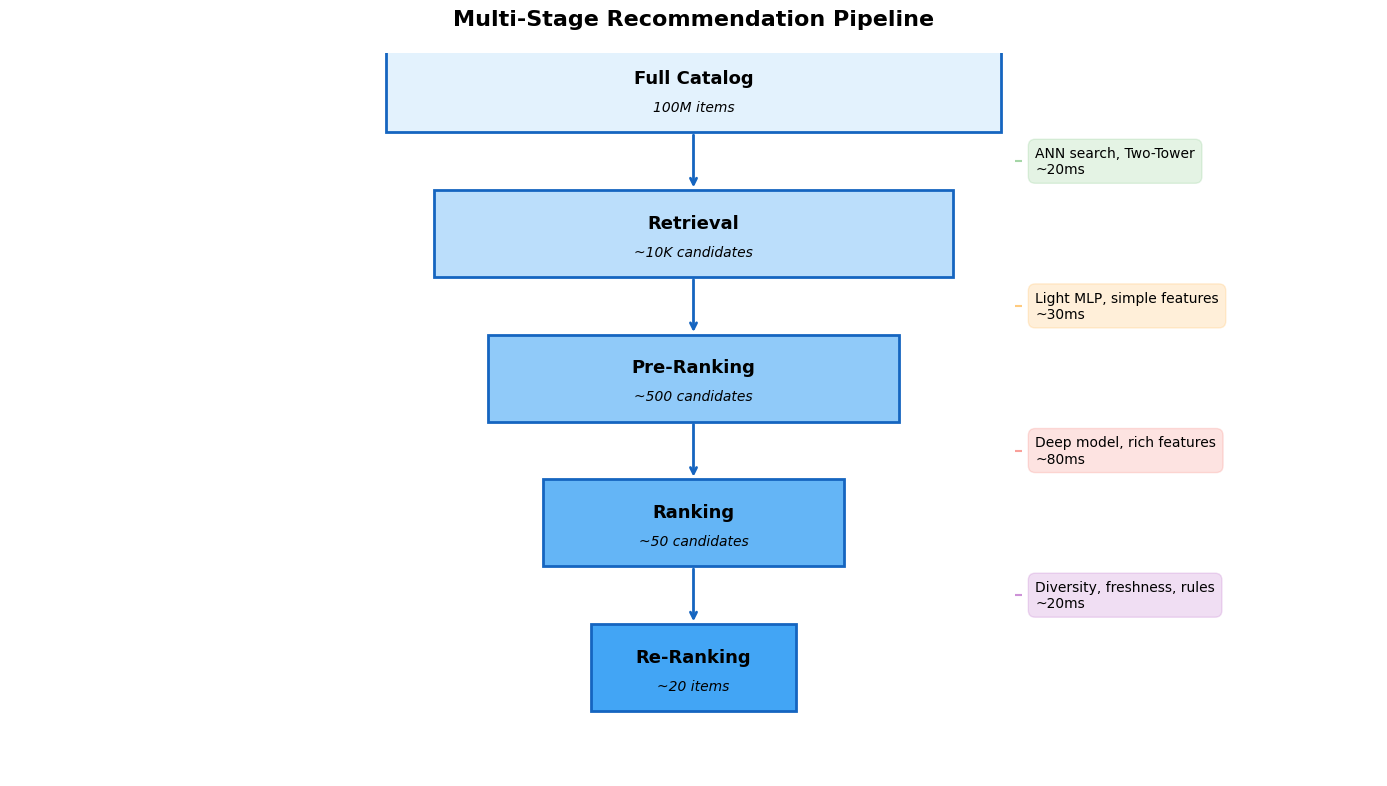

In [2]:
# Visualize the funnel
fig, ax = plt.subplots(figsize=(14, 8))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

stages = [
    ('Full Catalog', '100M items', 9.5, '#E3F2FD', 4.5),
    ('Retrieval', '~10K candidates', 7.5, '#BBDEFB', 3.8),
    ('Pre-Ranking', '~500 candidates', 5.5, '#90CAF9', 3.0),
    ('Ranking', '~50 candidates', 3.5, '#64B5F6', 2.2),
    ('Re-Ranking', '~20 items', 1.5, '#42A5F5', 1.5),
]

for name, desc, y, color, width in stages:
    rect = plt.Rectangle((5 - width/2, y - 0.6), width, 1.2,
                          facecolor=color, edgecolor='#1565C0', linewidth=2)
    ax.add_patch(rect)
    ax.text(5, y + 0.15, name, ha='center', va='center', fontsize=13, fontweight='bold')
    ax.text(5, y - 0.25, desc, ha='center', va='center', fontsize=10, style='italic')

# Arrows
for i in range(len(stages) - 1):
    y_start = stages[i][2] - 0.6
    y_end = stages[i+1][2] + 0.6
    ax.annotate('', xy=(5, y_end), xytext=(5, y_start),
                arrowprops=dict(arrowstyle='->', color='#1565C0', lw=2))

# Side annotations
side_notes = [
    (7.5, 8.5, 'ANN search, Two-Tower\n~20ms', '#4CAF50'),
    (7.5, 6.5, 'Light MLP, simple features\n~30ms', '#FF9800'),
    (7.5, 4.5, 'Deep model, rich features\n~80ms', '#F44336'),
    (7.5, 2.5, 'Diversity, freshness, rules\n~20ms', '#9C27B0'),
]

for x, y, text, color in side_notes:
    ax.text(x, y, text, ha='left', va='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.5', facecolor=color, alpha=0.15, edgecolor=color))
    ax.plot([5 + stages[0][4]/2 + 0.1, x - 0.1], [y, y], 
            color=color, linestyle='--', alpha=0.5)

ax.set_title('Multi-Stage Recommendation Pipeline', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## 2. Stage-by-Stage Deep Dive

### Stage 1: Retrieval (Candidate Generation)

Goal: quickly narrow down 100M items to ~10K candidates.

Methods:
- **Two-Tower Model**: Encode user and item separately, use ANN for fast lookup
- **Inverted Index**: Tag-based retrieval (user likes "action" -> all action items)
- **Collaborative Filtering**: Similar users' items, similar items
- **Multiple retrievers**: Combine results from different methods

$$
\text{score}(u, i) = \mathbf{e}_u^T \mathbf{e}_i \quad \text{(inner product in embedding space)}
$$

### Stage 2: Pre-Ranking (Coarse Ranking)

Goal: Reduce 10K to ~500 with a lightweight model that can use some cross-features.

- Simpler model than full ranker (fewer layers, fewer features)
- Can use basic user-item cross features
- Often uses knowledge distillation from the full ranker

### Stage 3: Ranking (Fine Ranking)

Goal: Score ~500 items with the most accurate model possible.

- Deep models: Wide&Deep, DeepFM, DCN, DIN, DIEN, etc.
- Rich features: user history, item attributes, context, cross-features
- Multi-task learning: CTR + conversion rate + watch time

### Stage 4: Re-Ranking

Goal: Apply business logic, diversity, and fairness constraints.

- **Diversity**: Avoid showing too many items from the same category
- **Freshness**: Boost newly added items
- **Business rules**: Promoted content, legal requirements
- **Listwise optimization**: Consider the entire page, not individual items

### Stage 5: Mix/Policy Layer

Goal: Blend results from different recommendation sources and apply final policies.

- Mix organic recommendations with ads
- Apply exploration (show some uncertain items to learn)
- A/B test routing
- Final presentation layout decisions

In [3]:
# Simulate the multi-stage pipeline
np.random.seed(42)

n_total_items = 100000
n_relevant = 100  # True relevant items for this user

# True relevance scores (unknown to the system)
true_relevance = np.zeros(n_total_items)
relevant_items = np.random.choice(n_total_items, n_relevant, replace=False)
true_relevance[relevant_items] = np.random.uniform(0.5, 1.0, n_relevant)

def simulate_retrieval(true_relevance, n_retrieve=10000, recall=0.7):
    """Simulate retrieval: high recall, some noise."""
    relevant = np.where(true_relevance > 0)[0]
    # Recall: fraction of relevant items retrieved
    n_rel_retrieved = int(len(relevant) * recall)
    retrieved_relevant = np.random.choice(relevant, n_rel_retrieved, replace=False)
    
    # Fill remaining slots with random items
    all_items = np.arange(len(true_relevance))
    remaining = np.setdiff1d(all_items, retrieved_relevant)
    random_fill = np.random.choice(remaining, n_retrieve - n_rel_retrieved, replace=False)
    
    retrieved = np.concatenate([retrieved_relevant, random_fill])
    # Noisy scores for retrieval
    scores = true_relevance[retrieved] + np.random.randn(len(retrieved)) * 0.3
    return retrieved, scores


def simulate_ranking(items, true_relevance, noise_std=0.1):
    """Simulate ranking: more accurate than retrieval."""
    scores = true_relevance[items] + np.random.randn(len(items)) * noise_std
    return scores


def ndcg_at_k(ranked_items, true_relevance, k):
    """Compute NDCG@K."""
    rels = true_relevance[ranked_items[:k]]
    dcg = np.sum((2**rels - 1) / np.log2(np.arange(2, k + 2)))
    # Ideal
    ideal_rels = np.sort(true_relevance)[::-1][:k]
    idcg = np.sum((2**ideal_rels - 1) / np.log2(np.arange(2, k + 2)))
    return dcg / idcg if idcg > 0 else 0


# Run pipeline
retrieved_items, retrieval_scores = simulate_retrieval(true_relevance)
# Sort by retrieval score, take top 500 for pre-ranking
top_retrieval = retrieved_items[np.argsort(retrieval_scores)[::-1][:500]]

# Ranking: more accurate scoring on 500 items
ranking_scores = simulate_ranking(top_retrieval, true_relevance, noise_std=0.05)
ranked_items = top_retrieval[np.argsort(ranking_scores)[::-1]]

# Evaluate at each stage
print("Pipeline Performance:")
print(f"{'Stage':<15} {'Items':<10} {'NDCG@10':<10} {'NDCG@50':<10} {'Recall@K':<10}")
print("-" * 55)

# Retrieval
retrieval_ranked = retrieved_items[np.argsort(retrieval_scores)[::-1]]
recall_retrieval = len(set(retrieval_ranked) & set(relevant_items)) / len(relevant_items)
print(f"{'Retrieval':<15} {len(retrieved_items):<10} {ndcg_at_k(retrieval_ranked, true_relevance, 10):<10.4f} "
      f"{ndcg_at_k(retrieval_ranked, true_relevance, 50):<10.4f} {recall_retrieval:<10.2%}")

# After ranking
recall_ranked = len(set(ranked_items) & set(relevant_items)) / len(relevant_items)
print(f"{'After Ranking':<15} {len(ranked_items):<10} {ndcg_at_k(ranked_items, true_relevance, 10):<10.4f} "
      f"{ndcg_at_k(ranked_items, true_relevance, 50):<10.4f} {recall_ranked:<10.2%}")

Pipeline Performance:
Stage           Items      NDCG@10    NDCG@50    Recall@K  
-------------------------------------------------------
Retrieval       10000      0.6571     0.4927     73.00%    
After Ranking   500        0.9461     0.8948     55.00%    


## 3. Meta's Recommendation Architecture

Meta (Facebook, Instagram, WhatsApp) serves billions of recommendations daily across News Feed, Stories, Reels, and Marketplace.

### Key Architectural Principles:

1. **Embedding-based Retrieval**: Two-tower models with FAISS for ANN search
2. **DLRM (Deep Learning Recommendation Model)**:
   - Separate handling of dense (continuous) and sparse (categorical) features
   - Feature interactions via embedding dot products
   - Top MLP for final prediction
3. **Multi-Task Learning**: Predict multiple objectives (click, like, share, comment, hide)
4. **Training Infrastructure**: Massive distributed training on custom hardware
5. **Real-time features**: User's recent actions are incorporated within seconds

### DLRM Architecture:
```
Dense Features -> Bottom MLP -> \
                                  -> Feature Interaction -> Top MLP -> Output
Sparse Features -> Embeddings -> /
```

> **🔑 Pro Tip:** Meta's DLRM paper (2019) revealed that recommendation models are fundamentally different from other DL workloads: they are dominated by embedding table lookups (memory-bound) rather than matrix multiplications (compute-bound). This insight drives their custom hardware designs.

In [4]:
import torch
import torch.nn as nn

class SimplifiedDLRM(nn.Module):
    """Simplified DLRM (Deep Learning Recommendation Model) - Meta's architecture."""
    
    def __init__(self, n_dense_features, sparse_feature_dims, emb_dim=16,
                 bottom_mlp_dims=[64, 32], top_mlp_dims=[64, 32, 1]):
        super().__init__()
        
        # Bottom MLP for dense features
        layers = []
        input_dim = n_dense_features
        for dim in bottom_mlp_dims:
            layers.extend([nn.Linear(input_dim, dim), nn.ReLU()])
            input_dim = dim
        # Project to emb_dim to match sparse embeddings
        layers.append(nn.Linear(input_dim, emb_dim))
        self.bottom_mlp = nn.Sequential(*layers)
        
        # Embedding tables for sparse features
        self.embeddings = nn.ModuleList([
            nn.Embedding(dim, emb_dim) for dim in sparse_feature_dims
        ])
        
        # Top MLP (takes interaction features)
        n_interactions = len(sparse_feature_dims) + 1  # +1 for dense
        n_pairs = n_interactions * (n_interactions - 1) // 2
        top_input_dim = n_pairs + emb_dim  # Pairwise interactions + bottom MLP output
        
        top_layers = []
        input_dim = top_input_dim
        for dim in top_mlp_dims[:-1]:
            top_layers.extend([nn.Linear(input_dim, dim), nn.ReLU()])
            input_dim = dim
        top_layers.append(nn.Linear(input_dim, top_mlp_dims[-1]))
        self.top_mlp = nn.Sequential(*top_layers)
    
    def interact(self, embeddings_list):
        """Compute pairwise dot-product interactions."""
        # Stack all embeddings: (batch, n_features, emb_dim)
        x = torch.stack(embeddings_list, dim=1)
        # Pairwise dot products
        interactions = torch.bmm(x, x.transpose(1, 2))  # (batch, n, n)
        # Extract upper triangle (excluding diagonal)
        n = x.size(1)
        triu_indices = torch.triu_indices(n, n, offset=1)
        return interactions[:, triu_indices[0], triu_indices[1]]  # (batch, n_pairs)
    
    def forward(self, dense_features, sparse_features):
        """
        Args:
            dense_features: (batch, n_dense) continuous features
            sparse_features: list of (batch,) tensors, one per sparse feature
        """
        # Bottom MLP for dense features
        dense_emb = self.bottom_mlp(dense_features)  # (batch, emb_dim)
        
        # Sparse embeddings
        sparse_embs = [emb(feat) for emb, feat in zip(self.embeddings, sparse_features)]
        
        # Feature interactions
        all_embs = [dense_emb] + sparse_embs
        interactions = self.interact(all_embs)  # (batch, n_pairs)
        
        # Concatenate and predict
        top_input = torch.cat([interactions, dense_emb], dim=1)
        return self.top_mlp(top_input).squeeze(-1)


# Demo
dlrm = SimplifiedDLRM(
    n_dense_features=5,
    sparse_feature_dims=[100, 50, 20, 10],  # user_id, item_id, category, device
    emb_dim=16
)

batch_size = 32
dense = torch.randn(batch_size, 5)
sparse = [torch.randint(0, d, (batch_size,)) for d in [100, 50, 20, 10]]

output = dlrm(dense, sparse)
print(f"DLRM output shape: {output.shape}")
print(f"Total parameters: {sum(p.numel() for p in dlrm.parameters()):,}")

DLRM output shape: torch.Size([32])
Total parameters: 9,713


## 4. Tencent's Recommendation Architecture

Tencent operates WeChat (1.3B+ users), QQ, Tencent Video, and WeChat Channels - each with massive recommendation needs.

### Key Architectural Features:

1. **Multi-Source Retrieval**: Combine CF-based, content-based, social graph-based, and trending-based retrieval channels
2. **Deep Interest Network variants**: Attention over user behavior for WeChat Channels
3. **Social Graph Integration**: Leverage WeChat's social connections for recommendations
4. **Multi-Modal Features**: Text, image, video features for content understanding
5. **Real-time System**: Feature computation and model serving within strict latency

### WeChat Channels Pipeline:
```
Multiple Retrieval Channels (Social + CF + Content + Trending)
         |
    Pre-ranking (light model)
         |
    Ranking (deep model with multi-task: click, duration, like, share)
         |
    Re-ranking (diversity, freshness, creator fairness)
         |
    Mix (organic + ads + promotions)
```

### Key Differences from Meta:
- **Social signal is primary**: WeChat's social graph is deeply integrated
- **Content diversity**: Stronger emphasis on content ecosystem health
- **Creator incentives**: Recommendation affects creator behavior and content supply

In [5]:
# Simulate multi-source retrieval (Tencent-style)
np.random.seed(42)

n_total = 50000
n_relevant = 200

# True relevance
true_rel = np.zeros(n_total)
rel_items = np.random.choice(n_total, n_relevant, replace=False)
true_rel[rel_items] = np.random.uniform(0.3, 1.0, n_relevant)

# Different retrieval channels have different recall/precision tradeoffs
def retrieve_channel(true_rel, channel_name, n_retrieve, recall, precision_boost):
    """Simulate a retrieval channel."""
    relevant = np.where(true_rel > 0)[0]
    n_rel = int(min(len(relevant) * recall, n_retrieve))
    rel_retrieved = np.random.choice(relevant, n_rel, replace=False)
    
    remaining = np.setdiff1d(np.arange(len(true_rel)), rel_retrieved)
    random_fill = np.random.choice(remaining, n_retrieve - n_rel, replace=False)
    
    items = np.concatenate([rel_retrieved, random_fill])
    scores = true_rel[items] * precision_boost + np.random.randn(len(items)) * 0.2
    return items, scores

channels = {
    'CF-based': {'n_retrieve': 3000, 'recall': 0.5, 'precision_boost': 1.0},
    'Content-based': {'n_retrieve': 2000, 'recall': 0.3, 'precision_boost': 0.8},
    'Social': {'n_retrieve': 2000, 'recall': 0.4, 'precision_boost': 1.2},
    'Trending': {'n_retrieve': 1000, 'recall': 0.2, 'precision_boost': 0.6},
}

# Run each channel
all_retrieved = set()
channel_results = {}

print(f"{'Channel':<15} {'Retrieved':<12} {'Relevant Found':<16} {'Recall':<10}")
print("-" * 55)

for name, params in channels.items():
    items, scores = retrieve_channel(true_rel, name, **params)
    channel_results[name] = (items, scores)
    all_retrieved.update(items)
    
    n_rel_found = np.sum(true_rel[items] > 0)
    channel_recall = n_rel_found / n_relevant
    print(f"{name:<15} {len(items):<12} {n_rel_found:<16} {channel_recall:<10.2%}")

# Combined recall
combined_relevant = sum(1 for i in all_retrieved if true_rel[i] > 0)
print(f"\n{'COMBINED':<15} {len(all_retrieved):<12} {combined_relevant:<16} {combined_relevant/n_relevant:<10.2%}")
print(f"\nKey insight: Combined recall ({combined_relevant/n_relevant:.1%}) > any single channel!")

Channel         Retrieved    Relevant Found   Recall    
-------------------------------------------------------
CF-based        3000         109              54.50%    
Content-based   2000         68               34.00%    
Social          2000         83               41.50%    
Trending        1000         45               22.50%    

COMBINED        7450         177              88.50%    

Key insight: Combined recall (88.5%) > any single channel!


## 5. Mapping to Real Products

| Product | Retrieval | Key Ranking Signal | Re-ranking Priority |
|---|---|---|---|
| **News Feed** (Meta) | Social graph + interests | Engagement (click, comment, share) | Diversity, recency |
| **TikTok/Reels** | CF + content + trending | Watch time, completion rate | Creator diversity, freshness |
| **E-commerce** (Amazon) | Search + CF + category | Purchase probability, revenue | Price range diversity |
| **WeChat Channels** | Social + CF + content | Multi-task (click, duration, like) | Social diversity, creator fairness |
| **YouTube** | CF + search + subscriptions | Watch time, satisfaction | Topic diversity, freshness |
| **Spotify** | CF + audio features | Listen probability, skip rate | Artist/genre diversity |

> **⚠️ Common Pitfall:** Optimizing purely for engagement (clicks, watch time) leads to filter bubbles and addictive patterns. Modern systems incorporate "responsibility" metrics like content diversity, user satisfaction surveys, and long-term retention.

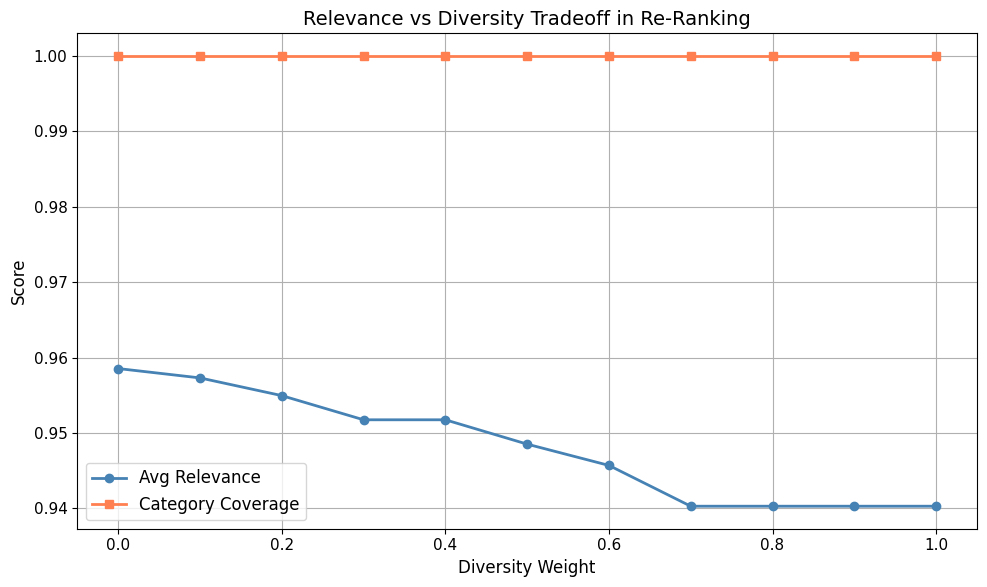

Notice the tradeoff: increasing diversity reduces average relevance.
The optimal point depends on the product's goals.


In [6]:
# Visualize the tradeoff between relevance and diversity in re-ranking
np.random.seed(42)

def simulate_reranking(ranked_items, true_relevance, item_categories, 
                       n_select=20, diversity_weight=0.0):
    """Greedy re-ranking with diversity."""
    selected = []
    selected_cats = []
    remaining = list(ranked_items[:100])  # Consider top 100
    
    for _ in range(n_select):
        best_score = -np.inf
        best_idx = 0
        
        for i, item in enumerate(remaining):
            relevance = true_relevance[item]
            # Diversity bonus: higher if category is underrepresented
            cat = item_categories[item]
            cat_count = selected_cats.count(cat)
            diversity = 1.0 / (1 + cat_count)  # Diminishing returns for same category
            
            score = (1 - diversity_weight) * relevance + diversity_weight * diversity
            
            if score > best_score:
                best_score = score
                best_idx = i
        
        selected.append(remaining[best_idx])
        selected_cats.append(item_categories[remaining[best_idx]])
        remaining.pop(best_idx)
    
    return np.array(selected)


# Create items with categories
n_cats = 5
item_cats = np.random.randint(0, n_cats, n_total)

# Try different diversity weights
diversity_weights = np.linspace(0, 1, 11)
relevance_scores_list = []
diversity_scores_list = []

# Get ranked items from previous simulation
all_items = list(all_retrieved)
all_scores = np.array([true_rel[i] for i in all_items])
sorted_idx = np.argsort(all_scores)[::-1]
ranked = np.array(all_items)[sorted_idx]

for dw in diversity_weights:
    reranked = simulate_reranking(ranked, true_rel, item_cats, n_select=20, diversity_weight=dw)
    
    # Relevance: average true relevance of selected items
    avg_rel = true_rel[reranked].mean()
    relevance_scores_list.append(avg_rel)
    
    # Diversity: number of unique categories
    n_unique_cats = len(set(item_cats[reranked]))
    diversity_scores_list.append(n_unique_cats / n_cats)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(diversity_weights, relevance_scores_list, 'o-', linewidth=2, label='Avg Relevance', color='steelblue')
ax.plot(diversity_weights, diversity_scores_list, 's-', linewidth=2, label='Category Coverage', color='coral')
ax.set_xlabel('Diversity Weight', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Relevance vs Diversity Tradeoff in Re-Ranking', fontsize=14)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

print("Notice the tradeoff: increasing diversity reduces average relevance.")
print("The optimal point depends on the product's goals.")

---

## Exercises

### 🏋️ Exercise 1: Design a Recommendation Pipeline

Design and simulate a recommendation pipeline for a music streaming service (like Spotify).

In [7]:
# TODO: Design a pipeline for a music streaming service.
# Consider:
# 1. What retrieval channels would you use?
#    - Collaborative filtering (similar listeners)
#    - Audio content similarity
#    - Genre/mood-based
#    - Social (friends' listening)
#    - Playlist-based
#
# 2. What features matter for ranking?
#    - Listen probability
#    - Skip probability  
#    - Expected listen duration
#    - User's current mood/context
#
# 3. What re-ranking rules would you apply?
#    - Artist diversity
#    - Genre diversity
#    - Explicit content filtering
#    - New release boosting
#
# Simulate each stage with synthetic data and measure:
# - Recall at each stage
# - NDCG at each stage
# - Diversity metrics
pass

### 🏋️ Exercise 2: Retrieval Channel Analysis

Analyze how different retrieval channels contribute to overall system performance.

In [8]:
# TODO:
# 1. Using the multi-source retrieval simulation above
# 2. For each channel, compute:
#    - Unique relevant items (items only this channel finds)
#    - Overlap with other channels
#    - Marginal recall contribution (what recall adds if we already have other channels)
# 3. Create a Venn-diagram style visualization showing channel overlaps
# 4. Rank channels by marginal contribution
# 5. Discuss: if you had to remove one channel, which would it be?
pass

### 🏋️ Exercise 3: Latency Budget Simulation

Model the latency of each pipeline stage and understand the compute-accuracy tradeoff.

In [9]:
# TODO:
# 1. Define latency models for each stage:
#    - Retrieval: ANN lookup time ~ O(log N) + network overhead
#    - Pre-ranking: time_per_item * n_items (light model)
#    - Ranking: time_per_item * n_items (heavy model)
#    - Re-ranking: O(n^2) for diversity
#
# 2. Given a total budget of 200ms, simulate different configurations:
#    - More retrieval candidates vs. more ranking candidates
#    - Faster ranking model vs. more features
#
# 3. For each configuration, estimate NDCG@20 and total latency
# 4. Plot the Pareto frontier (latency vs quality)
# 5. Identify the optimal configuration
pass

## Summary

In this notebook, we covered:

1. **Multi-stage pipeline**: Retrieval -> Pre-ranking -> Ranking -> Re-ranking -> Mix
2. **Why multi-stage**: The accuracy-efficiency tradeoff requires progressive filtering
3. **Meta's DLRM**: Embedding-based architecture for sparse + dense features
4. **Tencent's architecture**: Multi-source retrieval with social graph integration
5. **Real product mapping**: How the pipeline maps to News Feed, Video, E-commerce
6. **Relevance-diversity tradeoff**: The re-ranking stage balances multiple objectives

### Key Takeaways

- No single model can handle the full item catalog; multi-stage is necessary
- Each stage has different accuracy-latency requirements
- Multiple retrieval channels improve recall significantly
- Re-ranking is where business objectives (diversity, fairness) are enforced
- The best systems balance engagement with user well-being

### Next Up

In **Chapter 1.8**, we'll explore datasets and benchmarking - how to evaluate and compare recommendation systems rigorously.